In [9]:
from typing import List, Tuple, Dict
from dataclasses import dataclass

# Original NEAT use case

We train a tiny network to solve XOR.

In [10]:
import neat_tnp.neat_py_neat as neat

In [3]:
XOR_TABLE = {
    (0,0): 0,
    (0,1): 1,
    (1,0): 1,
    (1,1): 0,
}

def objective(genome: neat.Genome) -> float:
    error = 0
    for x1,x2 in XOR_TABLE.keys():
        answer = genome.specialization.forward(
            inputs=[x1,x2],
            nodes=genome.nodes,
            edges=genome.edges,
        )[0]
        correct = XOR_TABLE[(x1,x2)]
        error += (correct - answer)**2
    genome.fitness = 4 - error
    return genome.fitness

eval_batch = lambda genomes: [objective(g) for g in genomes]

top_genomes, stats, hist = neat.run(
    config=neat.NEATConfig(
        population_size=2000,
        special=neat.NEATOrigConfig(
            shape=(1,2),
        ),
    ),
    specialization_cls=neat.NEATOrigSpecialization,
    f_eval=eval_batch,
    # ngen=40,
    target_fit=3.99,
)

# test

genome = top_genomes[-1]
spec = genome.specialization
for (x1,x2),ans in XOR_TABLE.items():
    pred = spec.forward(
        inputs=[x1,x2],
        nodes=genome.nodes,
        edges=genome.edges,
    )[0]
    print(f"{x1}<>{x2}: {pred:.2f}; correct: {ans}")

Gen 0001 | Avg fit 002.7050 | Top fit 002.7050 | Species 1 | top species: 002.7050
Gen 0002 | Avg fit 002.6256 | Top fit 003.0322 | Species 1 | top species: 003.0322
Gen 0003 | Avg fit 002.8554 | Top fit 003.1327 | Species 1 | top species: 003.1327
Gen 0004 | Avg fit 002.9302 | Top fit 003.3339 | Species 1 | top species: 003.3339
Gen 0005 | Avg fit 002.9347 | Top fit 003.3858 | Species 1 | top species: 003.3858
Gen 0006 | Avg fit 002.9894 | Top fit 003.3929 | Species 1 | top species: 003.3929
Gen 0007 | Avg fit 003.0391 | Top fit 003.4565 | Species 1 | top species: 003.4565
Gen 0008 | Avg fit 003.0780 | Top fit 003.4761 | Species 1 | top species: 003.4761
Gen 0009 | Avg fit 003.0928 | Top fit 003.7225 | Species 1 | top species: 003.7225
Gen 0010 | Avg fit 003.1041 | Top fit 003.7638 | Species 1 | top species: 003.7638
Gen 0011 | Avg fit 003.0731 | Top fit 003.8586 | Species 1 | top species: 003.8586
Gen 0012 | Avg fit 003.0231 | Top fit 003.8586 | Species 1 | top species: 003.8586
Gen 

# Track Network Planning

Here we show our new use case of the core NEAT algorithm: network planning as a generalization of point-to-point path planning, in a cost map, with complex objectives.

In [11]:
import numpy as np
from skimage.draw import line_nd
from neat_tnp import neat_py_tnp as neat_tnp, plotting
import networkx as nx
import matplotlib.pyplot as plt

%matplotlib widget

In [12]:
# utilities

def matrix_trajectories_mask(mat: np.ndarray, edges: List[Tuple[Tuple[int,int],Tuple[int,int]]]):
    """
    Creates a mask of coverage of the provided edges over a matrix of shape mat.

    All contributions are scaled by the size of mat.
    """
    
    H, W = mat.shape

    # the coverage of all the edges in mat
    traces = np.zeros_like(mat)
    n_endpoints = np.zeros_like(mat)
    incident_edge_weights = np.zeros_like(mat)
    
    for p1,p2 in edges:
        if np.allclose(p1, p2):
            continue
        
        rows, cols = line_nd(p1, p2, endpoint=True)
        
        # filter out-of-bounds indices
        valid_mask = (rows >= 0) & (rows < H) & (cols >= 0) & (cols < W)
        rows, cols = rows[valid_mask], cols[valid_mask]
        n_points = len(rows)
        if n_points < 2:
            continue

        # remove the endpoints from the trace
        p1_row, p1_col = p1
        p2_row, p2_col = p2
        is_p1_mask = (rows == p1_row) & (cols == p1_col)
        is_p2_mask = (rows == p2_row) & (cols == p2_col)
        is_endpoint_mask = is_p1_mask | is_p2_mask
        edge_rows, edge_cols = rows[~is_endpoint_mask], cols[~is_endpoint_mask]
        end_rows, end_cols = rows[is_endpoint_mask], cols[is_endpoint_mask]
        
        weight = 1

        # ensure the traces respect euclidean distances
        #   * horizontal/vertical line  ->  c=1
        #   * diagonal line:            ->  c=sqrt(2)
        edge_vec = np.abs(np.array(p1) - np.array(p2))
        edge_vec = edge_vec / np.linalg.norm(edge_vec)
        di, dj = tuple(edge_vec)
        a, b = max(di, dj), min(di, dj)
        c_div_a = np.sqrt(a**2 + b**2)/a
        weight *= c_div_a

        # store traces
        traces[edge_rows,edge_cols] += weight
        n_endpoints[end_rows, end_cols] += 1
        incident_edge_weights[end_rows, end_cols] += weight
    
    # add contributions of edpoints (nodes)
    node_mask = n_endpoints>0
    traces[node_mask] += incident_edge_weights[node_mask]

    # scale the mask by the size of the map
    traces /= H+W

    return traces

def matrix_trajectories_masked(mat: np.ndarray, edges: List[Tuple[Tuple[int,int],Tuple[int,int]]]) -> float:
    """
    Computes the weight of a spatial graph (encoded as edge list) on
    a cost map (encoded as matrix).
    """
    total_coverage: np.ndarray = matrix_trajectories_mask(mat, edges)
    cost_map_masked = np.multiply(mat, total_coverage)
    final_sum = np.sum(cost_map_masked)
    assert not np.isnan(final_sum), f"cannot compute traces"
    return float(final_sum)

def genome_to_plot_graph(genome: neat_tnp.Genome, cost_map) -> plotting.PlotGraph:
    edges = []
    for conn in genome.edges.values():
        if conn.enabled:
            p1 = genome.nodes[conn.node1].data.pos
            p2 = genome.nodes[conn.node2].data.pos
            edges.append((p1, p2))
    
    edge_trajectories = matrix_trajectories_mask(cost_map, edges)

    return plotting.PlotGraph(
        fixed_nodes=[
            node.data.pos
            for node in genome.nodes.values()
            if node.data.type_ == neat_tnp.NodeType.Fixed
        ],
        dynamic_nodes=[
            node.data.pos
            for node in genome.nodes.values()
            if node.data.type_ == neat_tnp.NodeType.Flexible
        ],
        edges=edges,
        cost_map=cost_map,
        highlight=edge_trajectories,
    )

def avg_min_cut(nodes: Dict[neat_tnp.NodeID, neat_tnp.Node], edges: Dict[neat_tnp.EdgeID, neat_tnp.Edge], fixed_nodes: List[neat_tnp.NodeID]):
    G = nx.DiGraph()
    G.add_nodes_from(nodes.keys())
    for edge in edges.values():
        if edge.enabled:
            G.add_edge(edge.node1, edge.node2, capacity=1.0)
    min_cuts = []
    for i,n1 in enumerate(fixed_nodes):
        for n2 in fixed_nodes[i+1:]:
            cut_value, _ = nx.minimum_cut(G, n1, n2)
            min_cuts.append(cut_value)
    return sum(min_cuts)/len(min_cuts)


In [13]:
cost_map = np.array([
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 0, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
]) + 0.01
fixed_nodes = [
    (4, 5),
    (1, 1),
    (8, 1),
]

Gen 0001 | Avg fit 005.1581 | Top fit 005.1581 | Species 1 | top species: 005.1581
Gen 0002 | Avg fit 004.9288 | Top fit 016.0316 | Species 1 | top species: 016.0316
Gen 0003 | Avg fit 005.1343 | Top fit 023.5840 | Species 8 | top species: 011.5012, 023.5840, 004.0171, 004.2473, 003.4971
Gen 0004 | Avg fit 005.1747 | Top fit 023.5840 | Species 9 | top species: 011.7025, 022.8229, 023.5840, 004.4861, 005.6598
Gen 0005 | Avg fit 006.0644 | Top fit 023.9209 | Species 9 | top species: 023.9209, 023.5840, 015.7186, 011.7025, 013.0413
Gen 0006 | Avg fit 014.6981 | Top fit 046.6256 | Species 10 | top species: 023.0996, 024.6916, 023.9499, 023.2283, 046.6256
Gen 0007 | Avg fit 019.3685 | Top fit 060.7997 | Species 8 | top species: 060.7997, 024.6916, 025.5224, 023.1019, 024.5695

Target fitness 60 reached.

--- Evolution Finished ---
Top genome fitness: 60.79970429176863
Top graph:
--- Genome Graph ---
Fitness: 60.7997
Nodes:
  Node(data=NodeData(type_=<NodeType.Fixed: 0>, pos=(4, 5)), id=0)
 

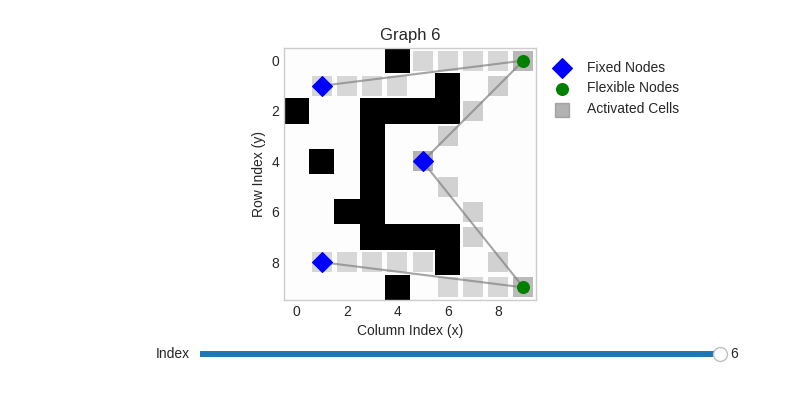

In [ ]:
def objective(genome: neat_tnp.Genome):
    connected = neat_tnp.check_connectivity(
        nodes=list(genome.nodes.keys()),
        edges={
            edge.id: (edge.node1, edge.node2)
            for edge in genome.edges.values()
            if edge.enabled
        }
    )
    map_cost = matrix_trajectories_masked(
        cost_map,
        edges=[
            (genome.nodes[edge.node1].data.pos, genome.nodes[edge.node2].data.pos)
            for edge in genome.edges.values()
            if edge.enabled
        ],
    )
    min_cut = avg_min_cut(
        nodes=genome.nodes,
        edges=genome.edges,
        fixed_nodes=[
            id
            for id,n in genome.nodes.items()
            if n.data.type_ == neat_tnp.NodeType.Fixed
        ]
    )
    if not connected:
        fitness = 0.0
    else:
        fitness = 1/max(map_cost, 1e-7)
        # ideally, have two paths between all fixed nodes
        if min_cut == 2:
            fitness += 20
    
    return fitness

eval_batched = lambda genomes: [objective(g) for g in genomes]

top_genomes, stats, hist = neat_tnp.run(
    config = neat_tnp.NEATConfig(
        population_size=400,
        species_threshold=0.8,
        special=neat_tnp.TNPConfig(
            grid_size=cost_map.shape,
            fixed_nodes=fixed_nodes,
        ),
    ),
    specialization_cls=neat_tnp.NEAT_TNP,
    ngen=50,
    target_fit=60,
    f_eval=eval_batched,
)

plotting.plot_graph_evolution([
    genome_to_plot_graph(genome=g, cost_map=cost_map) for g in top_genomes
])

## The Rust Implementation

To run this, you must first build the Rust-based NEAT-core and NEAT-TNP libraries. For that, you need to have Maturin installed. Then, you can run:

```bash
cd crates/neat_rs_tnp
maturin develop --release
cd ..
```

Gen 0001 | Avg fit 004.6949 | Top fit 008.2559 | Species 1 | top species: 008.2559
Gen 0002 | Avg fit 005.7829 | Top fit 015.5335 | Species 1 | top species: 015.5335
Gen 0003 | Avg fit 007.1564 | Top fit 015.6078 | Species 1 | top species: 015.6078
Gen 0004 | Avg fit 008.0799 | Top fit 065.5494 | Species 1 | top species: 065.5494
Gen 0005 | Avg fit 011.9233 | Top fit 065.5494 | Species 1 | top species: 065.5494
Gen 0006 | Avg fit 017.8424 | Top fit 065.5494 | Species 1 | top species: 065.5494
Gen 0007 | Avg fit 024.9436 | Top fit 067.9149 | Species 1 | top species: 067.9149
Gen 0008 | Avg fit 024.5311 | Top fit 067.9149 | Species 1 | top species: 067.9149
Gen 0009 | Avg fit 023.6372 | Top fit 069.6828 | Species 1 | top species: 069.6828
Gen 0010 | Avg fit 023.9210 | Top fit 069.6828 | Species 1 | top species: 069.6828
Gen 0011 | Avg fit 024.0254 | Top fit 069.6828 | Species 1 | top species: 069.6828
Gen 0012 | Avg fit 023.6736 | Top fit 069.6828 | Species 1 | top species: 069.6828
Gen 

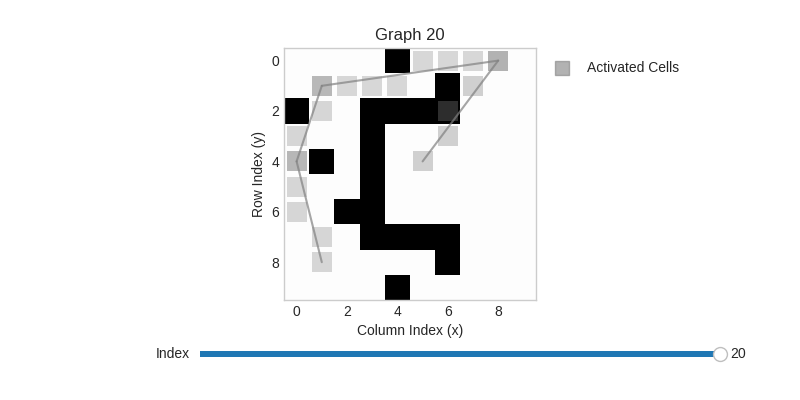

In [11]:
# the same benchmark using the Rust implementation

from neat_tnp import neat_rs_tnp

top_genomes, stats, hist = neat_rs_tnp.run(
    config = neat_rs_tnp.NEATConfig(
        population_size=500,
        species_threshold=2,
            special=neat_rs_tnp.TNPConfig(
            grid_size=cost_map.shape,
            fixed_nodes=fixed_nodes,
        ),
    ),
    cost_map=cost_map,
    ngen=20,
)

plotting.plot_graph_evolution([
    genome_to_plot_graph(
        genome=g,
        cost_map=cost_map,
    )
    for g in top_genomes
])